<a href="https://colab.research.google.com/github/arush242004/Finished-Projects/blob/main/PiccoloGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Important details about the model:

In [55]:
embedding_dimension = d_model = d_embed = 128
n_attention_heads = 4
n_transformer_blocks = 4
dropout = 0.1
vocab_size = 6000

torch.manual_seed(24)

In [94]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Data

In [56]:
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as functional
from torch.utils.data import TensorDataset, DataLoader

In [57]:
from tokenizers import Tokenizer
from tokenizers.models import BPE

tokenizer = Tokenizer(BPE())



---



# Mistake(s) made (and explanation on how to fix!):

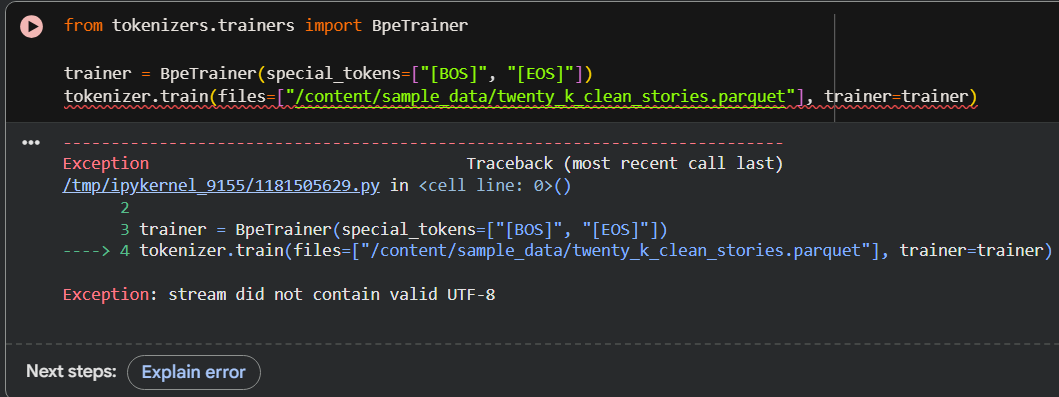

--

Here, tokenizer.train(files=[...]) expects each file in that list to be a plain UTF-8 text file — it reads the file byte-by-byte expecting to decode readable text out of it. But your file is '.parquet', and Parquet is a binary columnar format, i.e., compressed, structured, full of metadata and byte sequences that are absolutely not meant to be interpreted as UTF-8 text. When the Rust backend underneath tokenizers tries to read that file expecting text and instead finds Parquet's binary internals, it can't decode it — hence "stream did not contain valid UTF-8." The trainer isn't reading your dataset, it's reading a file format it doesn't understand and choking on the first invalid byte sequence it hits.

This is actually the flip side of a decision you made earlier and got right at the time: you chose Parquet over CSV specifically because it safely handles commas/quotes/newlines inside story text — a good call for storage. But the BPE trainer doesn't care about your storage format; it wants a corpus it can read as a stream of text. So you need one explicit conversion step in between: load the Parquet, pull out just the text column, and write it back out as a plain .txt file — one story per line is the standard convention.



---



In [58]:
import pandas as pd

df = pd.read_parquet("/content/sample_data/twenty_k_clean_stories.parquet")

In [59]:
import pandas as pd

df = pd.read_parquet("/content/sample_data/twenty_k_clean_stories.parquet")

with open("/content/sample_data/clean_stories.txt", "w", encoding="utf-8") as f:
    for story in df["text"]:
        f.write(story.strip() + "\n")

In [60]:
from tokenizers.trainers import BpeTrainer

trainer = BpeTrainer(vocab_size = 6000, special_tokens=["[BOS]", "[EOS]"])
tokenizer.train(files=["/content/sample_data/clean_stories.txt"], trainer=trainer)

In [61]:
output = tokenizer.encode("Hello, my name is Alice.")
print("These are the tokens: {}\nAnd these are the corresponding integer IDs: {}".format(output.tokens, output.ids))

These are the tokens: ['Hello, ', 'my ', 'name is ', 'Ali', 'ce', '.']
And these are the corresponding integer IDs: [5115, 239, 4611, 3523, 583, 15]


With this tokenizer trained on our corpus, we now pass the entire text file towards it to produce a long tensor of tokens (basically, tokenizing our entire text file to produce one long stream of tokens).

In [62]:
all_ids = []
for story in df["text"]:
    encoding = tokenizer.encode(story.strip())
    all_ids.extend(encoding.ids)
    all_ids.append(tokenizer.token_to_id("[EOS]"))

data = torch.tensor(all_ids, dtype=torch.long)

In [63]:
len(data)

3201432

## Creating the 'input' and 'output' labels

What we're building towards -

In [ ]:
'''
def get_batch(data, block_size, batch_size):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y
'''

### Problem -
You have one giant tensor of token IDs, data — say it's 5 million tokens long. You can't feed 5 million tokens into the model at once; that's absurdly long and there's no reason to. Instead, every training step, you want to grab a handful of short, random snippets from somewhere inside that giant tensor, and train on those. "A handful" is your ***batch_size*** (how many snippets at once), "short" is your ***block_size*** (how many tokens long each snippet is).

### a) Picking where each snippet starts:

For each of the batch_size snippets, you need a random starting position inside data. The one thing you have to be careful about: if you pick a starting position too close to the very end of data, there won't be enough tokens left after it to fill out a full block_size-length snippet. So the random starting position can't range all the way up to ***len(data)*** — it has to stop early enough that a full window still fits.

Put short; if data has ***len(data)*** tokens total, and each snippet needs ***block_size*** tokens, the last legal starting position is ***len(data)*** - ***block_size***. Anything later than that and you'd run off the edge trying to grab a full window. torch.randint generates random integers in *[low, high)* — low inclusive, high exclusive — so you want:

In [11]:
'''
ix = torch.randint(len(data) - block_size, (batch_size,))
                         ^ ^ ^ ^ ^ ^
                  This is the upper bound (which is exclusive)
                  The lower bound is 0 (which is inclusive)

                  So, we're taking a random sample of (batch_size)-number of
                  integers from the interval, [0, len(data) - block_size).
'''

"\nix = torch.randint(len(data) - block_size, (batch_size,))\n                         ^ ^ ^ ^ ^ ^\n                  This is the upper bound (which is exclusive)\n                  The lower bound is 0 (which is inclusive)\n\n                  So, we're taking a random sample of (batch_size)-number of\n                  integers from the interval, [0, len(data) - block_size).\n"

This gives you a tensor of ***batch_size*** random integers, each one a valid, safe starting index. ***ix*** stands for "indices" — it's not one number, it's a whole batch of them at once, one per snippet you're about to grab.

### b) Actually grabbing the snippets.

For every starting position ***i*** in ***ix*** , the input snippet is *data[i : i+block_size]* — a slice of block_size tokens starting at ***i***. You need one such slice per value of ***i*** in ***ix***, and then you need to stack all those individual slices into one single batched tensor. That's what *torch.stack* is for — it takes a list of same-shaped tensors and glues them together along a new dimension.

In [ ]:
'''
x = torch.stack([data[i:i+block_size] for i in ix])
'''

That list comprehension is doing exactly one thing per iteration: "grab this one window." *torch.stack* then takes all ***batch_size*** of those windows and produces one tensor of shape ***(batch_size, block_size)*** — your batched B, T shape.

### c) The labels

The model's job at every single position in the input is to predict the next token. So if your input window is tokens [5, 12, 3, 44], the label at each position should be "what actually came next" — which is just the same window, shifted one position to the right: [12, 3, 44, 91] (where 91 is whatever token in data comes right after the input window ends). That's why you grabbed block_size + 1 tokens' worth of room in step 1 — you need one extra token past the end of the input window to serve as the last label.

In [8]:
'''
y = torch.stack([data[i+1:i+block_size+1] for i in ix])
'''

'\ny = torch.stack([data[i+1:i+block_size+1] for i in ix])\n'

Putting all the 3 pieces together, we get:

In [64]:
def get_batch(data, block_size, batch_size):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

...and so, we pass the long stream of tokens we generated above this part into the ***get_batch*** function above.

In [65]:
block_size = embedding_dimension ## 128
batch_size = 50

inputs, outputs = get_batch(data, block_size, batch_size)

In [66]:
dataset = TensorDataset(inputs, outputs)
dataset = DataLoader(dataset)

And that is the data part of the problem done.

---

---

# Assembling the model.

We shall first document each aspect of the model first in our model-card below.

In [27]:
'''
embedding_dimension = d_model = d_embed = 128
n_attention_heads = 4
n_transformer_blocks = 4
dropout = 0.1
'''

'\nembedding_dimension = d_model = d_embed = 128\nn_attention_heads = 4\nn_transformer_blocks = 4\ndropout = 0.1\n'

## a) Absolute Positional Embedding

In [67]:
class AbsolutePositionalEmbedding(nn.Module):
  def __init__(self, d_embed, context_length=256):

    super().__init__()

    positional_embedding_matrix = torch.zeros(context_length, d_embed)
    positions = torch.arange(0, context_length).float().unsqueeze(1)

    div_term = torch.exp(torch.arange(0, d_embed, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_embed))

    positional_embedding_matrix[:, 0::2] = torch.sin(positions * div_term)
    positional_embedding_matrix[:, 1::2] = torch.cos(positions * div_term)

    self.register_buffer('positional_embedding_matrix', positional_embedding_matrix)

  def forward(self, word_embeddings):
    return word_embeddings + self.positional_embedding_matrix[:word_embeddings.size(-2), :]

## b) Attention Head

In [87]:
class Attention(nn.Module):
  def __init__(self, d_embed):

    super().__init__()

    self.d_embed = d_embed

    self.W_Q = nn.Linear(in_features=d_embed, out_features=int(d_embed/n_attention_heads), bias=False)
    self.W_K = nn.Linear(in_features=d_embed, out_features=int(d_embed/n_attention_heads), bias=False)
    self.W_V = nn.Linear(in_features=d_embed, out_features=int(d_embed/n_attention_heads), bias=False)

  def forward(self, embedding_vectors, mask):
    Q = self.W_Q(embedding_vectors)
    K = self.W_K(embedding_vectors)
    V = self.W_V(embedding_vectors)

    product_matrix = torch.matmul(Q, K.transpose(-2, -1))
    scaled_product_matrix = product_matrix / (K.size(-1)**0.5)
    scaled_product_matrix = scaled_product_matrix.masked_fill(mask=mask, value=float('-inf'))

    attention_map = functional.softmax(scaled_product_matrix, dim=-1)
    attention_scores = torch.matmul(attention_map, V)

    return attention_scores

## c) Multi-Head Self-Attention

In [69]:
class MHSA(nn.Module):
  def __init__(self, d_embed):

    super().__init__()
    self.d_embed = d_embed
    self.W_O = nn.Linear(in_features=d_embed, out_features=d_embed, bias=False)
    self.attention_head_1 = Attention(d_embed)
    self.attention_head_2 = Attention(d_embed)
    self.attention_head_3 = Attention(d_embed)
    self.attention_head_4 = Attention(d_embed)

    causal_mask = torch.tril(torch.ones(block_size, block_size)) == 0
    self.register_buffer('mask', causal_mask)

  def forward(self, embedding_vectors):

    T = embedding_vectors.size(-2)
    mask = self.mask[:T, :T]

    head1_output = self.attention_head_1(embedding_vectors, mask)
    head2_output = self.attention_head_2(embedding_vectors, mask)
    head3_output = self.attention_head_3(embedding_vectors, mask)
    head4_output = self.attention_head_4(embedding_vectors, mask)

    concatenated_output = torch.concat([head1_output,
                                       head2_output,
                                       head3_output,
                                       head4_output],
                                       dim=-1)

    return self.W_O(concatenated_output)

## d) LayerNorm

This is already a class - nn.LayerNorm(...)

## e) FFN


In [77]:
class FFN(nn.Module):

  def __init__(self, d_embed):
    super().__init__() # This line was missing
    self.d_embed = d_embed
    self.Layer_1 = nn.Linear(in_features=d_embed, out_features=4*d_embed, bias=True)
    self.relu = nn.ReLU()
    self.Layer_2 = nn.Linear(in_features=4*d_embed, out_features=d_embed, bias=True)

  def forward(self, embedding_vectors):
    return self.Layer_2(self.relu(self.Layer_1(embedding_vectors)))

# Assembling the Model.


a) The Embedding Layer

In [71]:
class EmbeddingLayer(nn.Module):
  def __init__(self, d_embed):
    super().__init__()

    self.d_embed = d_embed
    self.EmbeddingMatrix = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_embed)
    self.APE = AbsolutePositionalEmbedding(d_embed, context_length=256)

  def forward(self, token_ids):
    raw_embedding_vectors = self.EmbeddingMatrix(token_ids)
    final_embedding_vectors = self.APE(raw_embedding_vectors)

    return final_embedding_vectors

b) Defining one Transformer Block

In [72]:
class Transformer_Block(nn.Module):

  def __init__(self, d_embed):

    super().__init__()

    self.d_embed = d_embed

    self.MHSA_block = MHSA(d_embed)

    ## Residual connection-1 is part of the forward() method...

    self.LayerNorm_1 = nn.LayerNorm(d_embed)

    self.FFN_layer = FFN(d_embed)

    ## Residual connection-2 is part of the forward() method...

    self.LayerNorm_2 = nn.LayerNorm(d_embed)


  def forward(self, embedding_vectors):

    attention_info = self.MHSA_block(embedding_vectors)

    residual_connection_1 = embedding_vectors + attention_info


    LayerNorm_1 = self.LayerNorm_1(residual_connection_1)


    FFN_output = self.FFN_layer(LayerNorm_1)


    residual_connection_2 = LayerNorm_1 + FFN_output


    LayerNorm_2 = self.LayerNorm_2(residual_connection_2)

    return LayerNorm_2

Putting both together...

In [75]:
class PiccoloClass(nn.Module):
  def __init__(self, d_embed):

    super().__init__()

    self.d_embed = d_embed
    self.EmbeddingLayer = EmbeddingLayer(d_embed)
    self.Transformer_Block_1 = Transformer_Block(d_embed)
    self.Transformer_Block_2 = Transformer_Block(d_embed)
    self.Transformer_Block_3 = Transformer_Block(d_embed)
    self.Transformer_Block_4 = Transformer_Block(d_embed)
    self.FinalLayerNorm = nn.LayerNorm(d_embed)
    self.OutputProjection = nn.Linear(in_features=d_embed, out_features=6000, bias=True)

  def forward(self, token_ids):
    embedding_vectors = self.EmbeddingLayer(token_ids)

    final_hidden = self.Transformer_Block_4(
                        self.Transformer_Block_3(
                            self.Transformer_Block_2(
                                self.Transformer_Block_1(embedding_vectors))))

    normalized_output = self.FinalLayerNorm(final_hidden)
    logits = self.OutputProjection(normalized_output)
    return logits

# Creating Piccolo

In [90]:
Piccolo = PiccoloClass(d_embed)

# Training Piccolo

The below is the function for inference:

In [80]:
def generate(model, tokenizer, prompt="", max_new_tokens=200):
    model.eval()

    if prompt:
        input_ids = tokenizer.encode(prompt).ids
    else:
        input_ids = [tokenizer.token_to_id("[BOS]")]

    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0)  # add a batch dim -> (1, T)

    for _ in range(max_new_tokens):
        context = input_ids[:, -block_size:]  # crop to the last block_size tokens — the model can never see further back than this

        with torch.no_grad():
            logits = model(context)

        next_token_logits = logits[:, -1, :]  # only the prediction that follows the very last token matters
        probs = functional.softmax(next_token_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)  # sample from the distribution, don't always take the argmax — greedy decoding tends to repeat itself

        input_ids = torch.cat([input_ids, next_token], dim=1)

        if next_token.item() == tokenizer.token_to_id("[EOS]"):
            break

    model.train()
    return tokenizer.decode(input_ids[0].tolist())

The below is the script for training:

In [96]:
optimizer = torch.optim.AdamW(Piccolo.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()

max_iters = 5000       # adjust once you see the timing estimate below
eval_interval = 500

import time
start_time = time.time()

for iter in range(max_iters):
    x_batch, y_batch = get_batch(data, block_size, batch_size)

    logits = Piccolo(x_batch)  # (batch_size, block_size, vocab_size)

    # CrossEntropyLoss wants (N, C) predictions and (N,) targets — flatten batch and position together
    B, T, C = logits.shape
    loss = loss_fn(logits.view(B * T, C), y_batch.view(B * T))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter == 99:
        elapsed = time.time() - start_time
        projected_minutes = (elapsed / 100) * max_iters / 60
        print(f"First 100 iterations took {elapsed:.1f}s -> projected {projected_minutes:.1f} min for all {max_iters} iterations")

    if iter % eval_interval == 0 or iter == max_iters - 1:
        print(f"step {iter}: loss = {loss.item():.4f}")
        print(f"sample: {generate(Piccolo, tokenizer, max_new_tokens=100)}\n")

        torch.save({
            'iter': iter,
            'model_state_dict': Piccolo.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }, '/content/drive/MyDrive/piccolo_checkpoint.pt')

step 0: loss = 5.3247
sample: c smiled and said, " O t  is not  your . You can  do  my  garden ."
 
 Tom was  luck y to  respect . The girl  !" Lily  says. " You  us . I  don't want to   asked.
 
 Ben  hears  Tim and  Lila s are  not  always  play with  me ."  Lily  says  was a  hug . She said  back  with a  smile  again.
 
 They  hug  their  grandma  go to  something  has a  sharp  pain t the  bread  some  su e and  not t  in the  villa learned  things  their  car and  open . He  .
 
 Lily  pet .
 
 " Are you  even , but  we  should  be  there  is a  smart  dog s. They  want to  play with  my  new  plan ?" he  stop ."
 
 They  looked at  each other and  can 

First 100 iterations took 204.3s -> projected 170.3 min for all 5000 iterations
step 500: loss = 4.9029
sample: fancy  cool  and  wait , so  no one  would  spread  that  was very  ba d. He  looked  funn y.
 
 One day,  Mittens  held  gu ea sil ver  he was  crying and  it was  her  daddy  would  paint  in the  op  around the  trie

# Saving Piccolo

Saving Piccolo's weights:

In [135]:
torch.save(Piccolo.state_dict(), "piccolo_weights.pt")

Saving Piccolo's tokenizer:

In [136]:
tokenizer.save("piccolo_tokenizer.json")

To bring him back later, in a fresh session; rebuild the model with the same hyperparameters (d_embed=128, same n_head, n_layer, block_size, vocab_size — worth jotting these down somewhere alongside the saved files, since state_dict alone doesn't record them), then:

In [ ]:
'''
model = PiccoloClass(d_embed)          # same hyperparameters as training
model.load_state_dict(torch.load("piccolo_weights.pt"))
model.eval()

from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("piccolo_tokenizer.json")
'''

...and generate(model, tokenizer, ...) works exactly as it did during training.